# 🏠 End-to-End House Price Predictor

> **Production-ready scikit-learn Pipeline** · California Housing Dataset

---
### What this notebook covers
1. Load the real **California Housing** dataset
2. train/test split — split first, transform later
3. Custom `IQRCapper` transformer (no leakage)
4. Custom `HousingFeatureEngineer` transformer
5. Full `sklearn.Pipeline`: cap → engineer → impute → scale → model
6. `RandomizedSearchCV` for hyperparameter tuning
7. Cross-validation + test evaluation
8. Feature importance: `feature_importances_` vs `permutation_importance`
9. Save, load, and validate before inference

In [1]:
# ── Install / upgrade deps ────────────────────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1 · Load the California Housing Dataset

scikit-learn ships the real California Housing dataset — **20 640** census block records derived from the 1990 US Census.  
The target (`MedHouseVal`) is median house value in units of $100K.

> 💡 **Rule #1 of ML pipelines:** load raw data, then immediately split. Every transformation comes after.

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df = df.rename(columns={'MedHouseVal': 'price'})

print(f'Shape       : {df.shape}')
print(f'Features    : {list(housing.feature_names)}')
print(f'Missing vals: {df.isnull().sum().sum()}')
print(f'Target range: ${df["price"].min()*100_000:,.0f} – ${df["price"].max()*100_000:,.0f}')
df.head()

Shape       : (20640, 9)
Features    : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Missing vals: 0
Target range: $14,999 – $500,001


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2 · Train / Test Split — FIRST, before anything else

**Why here?**  
Every transformation (scaling, capping, feature engineering) must be *fitted* only on training data.  
If you transform before splitting, information from the test set leaks into training — this is called **data leakage**.  
The model will appear to perform better than it actually does on truly unseen data.

> ✅ Golden rule: `train_test_split` is always the **first** operation after loading data.

In [4]:
TARGET  = 'price'
NUMERIC = [c for c in df.columns if c != TARGET]

X = df[NUMERIC]
y = df[TARGET]

# ── Split FIRST ───────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}   ({len(X_test)/len(X)*100:.0f}%)')
print('\n✅ Split done. No transformations have touched the data yet.')

Train : (16512, 8)  (80%)
Test  : (4128, 8)   (20%)

✅ Split done. No transformations have touched the data yet.


## 3 · Custom Transformer: IQRCapper

Here we wrap it in a proper `sklearn` transformer so the Pipeline handles it correctly:
- `fit()` learns the IQR bounds **from training data only**
- `transform()` applies those same bounds to any data (train or test)

> 💡 Any operation that *learns something from data* must implement `fit()`. This is the core principle behind sklearn's Transformer API.

In [5]:
class IQRCapper(BaseEstimator, TransformerMixin):
    """
    Clips each feature to [Q1 - 1.5*IQR, Q3 + 1.5*IQR] bounds.
    Bounds are fitted only on training data to prevent leakage.
    """

    def __init__(self, factor: float = 1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = pd.DataFrame(X)  # handle both DataFrame and numpy array input
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr  # learned from TRAIN only
        self.upper_ = q3 + self.factor * iqr  # learned from TRAIN only
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return np.clip(X, self.lower_.values, self.upper_.values)


# ── Sanity check ──────────────────────────────────────────────────────────────
capper = IQRCapper()
capper.fit(X_train)
changed_train = (X_train.values != capper.transform(X_train)).sum()
print(f'✅ IQRCapper fitted on train only.')
print(f'   Values capped in X_train: {changed_train}')
print(f'   Bounds learned (first 3 features):')
for col in X_train.columns[:3]:
    print(f'   {col:20s}  lower={capper.lower_[col]:.3f}  upper={capper.upper_[col]:.3f}')

✅ IQRCapper fitted on train only.
   Values capped in X_train: MedInc         529
HouseAge         0
AveRooms       410
AveBedrms     1153
Population     955
AveOccup       582
Latitude         0
Longitude        0
dtype: int64
   Bounds learned (first 3 features):
   MedInc                lower=-0.743  upper=8.083
   HouseAge              lower=-10.500  upper=65.500
   AveRooms              lower=2.039  upper=8.475


## 4 · Custom Transformer: HousingFeatureEngineer

Feature engineering also belongs inside the Pipeline.  
Even though it doesn't *learn* from data, encapsulating it here means:
- It runs automatically during CV, prediction, and model reloading
- You can't forget to apply it to new data
- The transformation logic is version-controlled with the model

> 💡 If you do feature engineering outside the Pipeline, you'll have to manually repeat those steps every time you predict — and eventually you'll forget one.

In [6]:
class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Adds 4 domain-informed features to the California Housing dataset.

    New features:
        rooms_per_bedroom  — spaciousness signal
        pop_density_proxy  — neighborhood density proxy
        dist_sf            — Euclidean distance to San Francisco
        income_sq          — captures non-linear income effect on price

    Expected input columns (in this order, matching fetch_california_housing):
        MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
    """

    def fit(self, X, y=None):
        # Stateless transformer — nothing to learn
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=[
            'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude'
        ])
        X = X.copy()

        # Guard against zero denominators — NaN is handled by SimpleImputer downstream
        X['rooms_per_bedroom'] = X['AveRooms'] / (X['AveBedrms'].replace(0, np.nan))
        X['pop_density_proxy'] = X['Population'] / (X['AveOccup'].replace(0, np.nan))
        X['dist_sf']           = np.sqrt((X['Latitude'] - 37.77)**2 + (X['Longitude'] + 122.42)**2)
        X['income_sq']         = X['MedInc'] ** 2

        return X.values  # return numpy array for sklearn compatibility


print('✅ HousingFeatureEngineer defined.')
print(f'   Input  features : {len(NUMERIC)}')
print(f'   Output features : {len(NUMERIC) + 4}  (+4 engineered)')

✅ HousingFeatureEngineer defined.
   Input  features : 8
   Output features : 12  (+4 engineered)


## 5 · Build the Full Pipeline

All steps are chained in one object:

```
raw data
  → IQRCapper        (clip outliers using TRAIN bounds)
  → FeatureEngineer  (add 4 new features)
  → SimpleImputer    (fill any NaN produced by zero-division guards)
  → StandardScaler   (normalize to mean=0, std=1)
  → GradientBoosting (predict)
```

> 💡 The Pipeline guarantees that during cross-validation, every fold only uses training-fold statistics for `fit`. Test folds are always transformed with training-derived parameters — never their own.

In [7]:
pipeline = Pipeline([
    ('capper',      IQRCapper(factor=1.5)),
    ('engineer',    HousingFeatureEngineer()),
    ('imputer',     SimpleImputer(strategy='median')),
    ('scaler',      StandardScaler()),
    ('regressor',   GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.8,
        random_state=42,
    )),
])

print('Pipeline steps:')
for name, step in pipeline.steps:
    print(f'  [{name}]  {step.__class__.__name__}')

Pipeline steps:
  [capper]  IQRCapper
  [engineer]  HousingFeatureEngineer
  [imputer]  SimpleImputer
  [scaler]  StandardScaler
  [regressor]  GradientBoostingRegressor


## 6 · Hyperparameter Search with RandomizedSearchCV

v1 hardcoded `n_estimators=300, max_depth=5` without justification.  
Here we search over a parameter grid to find better values systematically.

**Why `RandomizedSearchCV` over `GridSearchCV`?**  
Grid search tries every combination — exponential cost.  
Randomized search samples `n_iter` random combinations — finds good params much faster with marginal quality loss.

> ⚠️ Note: `n_iter=20, cv=3` is set for Colab speed. In production, use `n_iter=100, cv=5`.

In [11]:
param_dist = {
    'regressor__n_estimators':  [100, 200, 300, 400, 500],
    'regressor__max_depth':     [3, 4, 5, 6, 7],
    'regressor__learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'regressor__subsample':     [0.7, 0.8, 0.9, 1.0],
    'capper__factor':           [1.5, 2.0, 2.5],  # also tuning our custom transformer!
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,          # try 20 random combinations
    cv=3,               # 3-fold CV per combination
    scoring='r2',
    random_state=42,
    n_jobs=-1,          # use all CPU cores
    verbose=2,
)

print('🔍 Running RandomizedSearchCV (20 iterations × 3 folds = 60 fits)...')
search.fit(X_train, y_train)

print(f'\n✅ Best CV R²  : {search.best_score_:.4f}')
print(f'Best params   :')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

# Use best pipeline from now on
pipeline = search.best_estimator_

🔍 Running RandomizedSearchCV (20 iterations × 3 folds = 60 fits)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best CV R²  : 0.8407
Best params   :
  regressor__subsample: 0.7
  regressor__n_estimators: 400
  regressor__max_depth: 6
  regressor__learning_rate: 0.08
  capper__factor: 2.5


## 7 · Cross-Validate + Final Test Evaluation

> ⚠️ The test set is used **exactly once** - here at the very end.  
> Looking at test metrics multiple times to tune hyperparameters would be another form of leakage.

5-Fold CV R²: 0.8436 ± 0.0054

📈 Test Metrics
   RMSE : 0.4476  ($44,757)
   MAE  : 0.2925  ($29,249)
   R²   : 0.8471


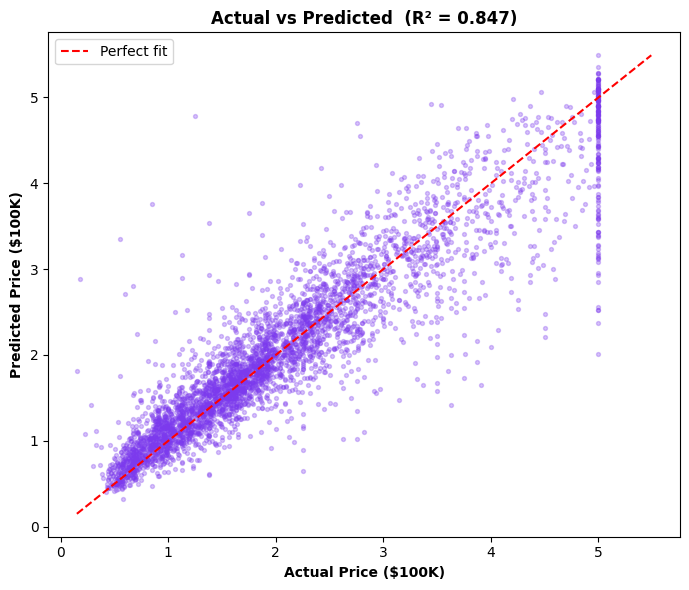

In [12]:
# 5-fold CV on training data to get an unbiased performance estimate
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
print(f'5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Final evaluation — test set touched only once
y_pred = pipeline.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
mae    = mean_absolute_error(y_test, y_pred)
r2     = r2_score(y_test, y_pred)

print(f'\n📈 Test Metrics')
print(f'   RMSE : {rmse:.4f}  (${rmse*100_000:,.0f})')
print(f'   MAE  : {mae:.4f}  (${mae*100_000:,.0f})')
print(f'   R²   : {r2:.4f}')

# Actual vs Predicted scatter
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=8, color='#7c3aed')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
plt.xlabel('Actual Price ($100K)', fontweight='bold')
plt.ylabel('Predicted Price ($100K)', fontweight='bold')
plt.title(f'Actual vs Predicted  (R² = {r2:.3f})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 8 · Feature Importance: Two Methods

### Method 1 — `feature_importances_` (built-in, fast)
Measures how much each feature reduced impurity across all trees.  
**Limitation:** systematically overestimates high-cardinality features.

### Method 2 — `permutation_importance` (slower, more reliable)
Randomly shuffles one feature at a time and measures how much the model's score drops.  
**Advantage:** measures actual impact on predictions, not internal tree structure.  
This is the preferred method for reporting results.

In [14]:
# ── Feature names after engineering (8 original + 4 engineered) ───────────────
FEATURE_NAMES = list(NUMERIC) + ['rooms_per_bedroom', 'pop_density_proxy', 'dist_sf', 'income_sq']

# ── Method 1: Built-in feature importances ────────────────────────────────────
fi_builtin = pipeline.named_steps['regressor'].feature_importances_
fi_df = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': fi_builtin})
fi_df = fi_df.sort_values('importance', ascending=True)

# ── Method 2: Permutation importance on TEST set ──────────────────────────────
# We need to transform X_test through the pipeline up to (not including) the regressor
# and then apply permutation_importance to the regressor directly.

# Extract the preprocessor part of the pipeline
preprocessor_pipeline = Pipeline(pipeline.steps[:-1])
X_test_transformed_for_regressor = preprocessor_pipeline.transform(X_test)

perm_result = permutation_importance(
    pipeline.named_steps['regressor'], # Apply to the regressor directly
    X_test_transformed_for_regressor, # Use the transformed data (12 features)
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=True)

print('Top 5 features by permutation importance (most reliable):')
print(perm_df.tail(5)[['feature', 'importance_mean', 'importance_std']].to_string(index=False))


Top 5 features by permutation importance (most reliable):
  feature  importance_mean  importance_std
 AveOccup         0.129440        0.003580
income_sq         0.244861        0.007335
  dist_sf         0.799238        0.009785
Longitude         1.082664        0.010762
 Latitude         2.226035        0.042627


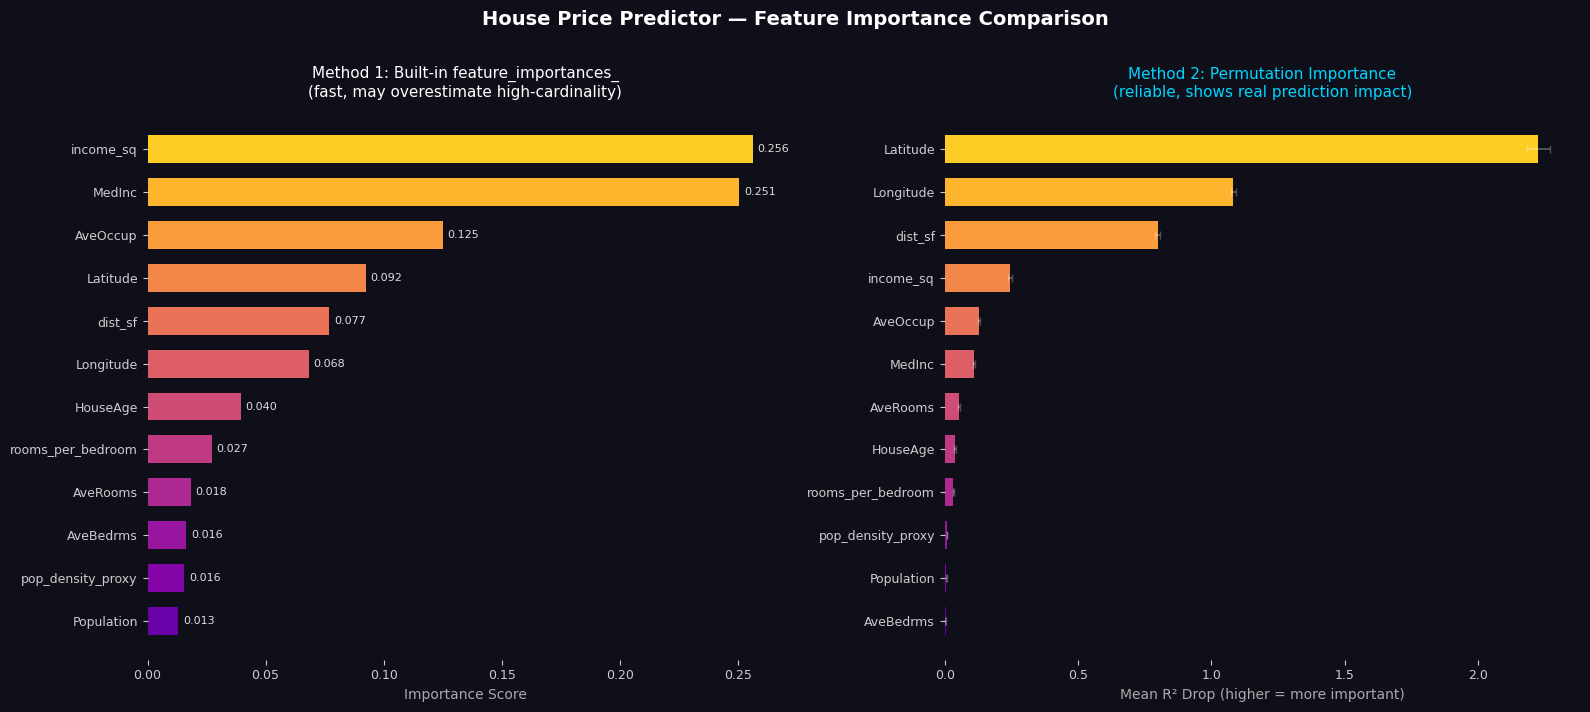

Saved → feature_importance_v2.png


In [16]:
# ── Dashboard: Built-in (left) vs Permutation (right) ─────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0f0f1a')
cmap = plt.cm.plasma

# Left: built-in
colors_l = [cmap(v) for v in np.linspace(0.2, 0.9, len(fi_df))]
bars = axes[0].barh(fi_df['feature'], fi_df['importance'], color=colors_l, edgecolor='none', height=0.65)
axes[0].set_facecolor('#0f0f1a')
axes[0].spines[:].set_visible(False)
axes[0].tick_params(colors='#cccccc', labelsize=9)
axes[0].set_xlabel('Importance Score', color='#aaaaaa')
axes[0].set_title('Method 1: Built-in feature_importances_\n(fast, may overestimate high-cardinality)', color='white', fontsize=11, pad=10)
for bar, val in zip(bars, fi_df['importance']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', color='#dddddd', fontsize=8)

# Right: permutation
colors_r = [cmap(v) for v in np.linspace(0.2, 0.9, len(perm_df))]
bars2 = axes[1].barh(perm_df['feature'], perm_df['importance_mean'],
                      xerr=perm_df['importance_std'],
                      color=colors_r, edgecolor='none', height=0.65,
                      error_kw={'ecolor': '#ffffff44', 'capsize': 3})
axes[1].set_facecolor('#0f0f1a')
axes[1].spines[:].set_visible(False)
axes[1].tick_params(colors='#cccccc', labelsize=9)
axes[1].set_xlabel('Mean R² Drop (higher = more important)', color='#aaaaaa')
axes[1].set_title('Method 2: Permutation Importance\n(reliable, shows real prediction impact)', color='#00d4ff', fontsize=11, pad=10)

fig.suptitle('House Price Predictor — Feature Importance Comparison',
             color='white', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved → feature_importance_v2.png')

## 9 · Save Model & Validate Input Before Inference


Production systems should validate inputs before calling `.predict()` to:
- Catch missing required fields early with a clear error message
- Prevent silent NaN propagation through the pipeline
- Make the API contract explicit

In [17]:
joblib.dump(pipeline, 'house_price_model_v2.pkl')
print('💾 Model saved → house_price_model_v2.pkl')

💾 Model saved → house_price_model_v2.pkl


In [18]:
def validate_input(data: dict) -> pd.DataFrame:
    """
    Validates a single house record before prediction.
    Raises ValueError with a clear message if required fields are missing
    or contain invalid values.

    Expected keys: MedInc, HouseAge, AveRooms, AveBedrms,
                   Population, AveOccup, Latitude, Longitude
    """
    REQUIRED_FIELDS = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                       'Population', 'AveOccup', 'Latitude', 'Longitude']

    # 1. Check for missing fields
    missing = [f for f in REQUIRED_FIELDS if f not in data]
    if missing:
        raise ValueError(f'Missing required fields: {missing}')

    # 2. Check for None values in required fields
    nulls = [f for f in REQUIRED_FIELDS if data.get(f) is None]
    if nulls:
        raise ValueError(f'Fields cannot be None: {nulls}')

    # 3. Check basic domain constraints
    if data['MedInc'] < 0:
        raise ValueError(f'MedInc cannot be negative: {data["MedInc"]}')
    if not (-90 <= data['Latitude'] <= 90):
        raise ValueError(f'Latitude out of valid range: {data["Latitude"]}')
    if not (-180 <= data['Longitude'] <= 180):
        raise ValueError(f'Longitude out of valid range: {data["Longitude"]}')

    # 4. Return as DataFrame with only the model's expected columns (in order)
    return pd.DataFrame([{k: data[k] for k in REQUIRED_FIELDS}])


def predict_price(model, raw_input: dict) -> float:
    """Validates input and returns predicted price in dollars."""
    df_input = validate_input(raw_input)
    pred = model.predict(df_input)[0]
    return pred * 100_000


print('✅ validate_input() and predict_price() defined.')

✅ validate_input() and predict_price() defined.


In [19]:
# ── Load saved model and run demo predictions ─────────────────────────────────
loaded_model = joblib.load('house_price_model_v2.pkl')
print('✅ Model loaded successfully.')
print('Pipeline steps:', [name for name, _ in loaded_model.steps])

# --- Demo 1: Valid house near San Francisco ---
house_sf = {
    'MedInc':     6.5,
    'HouseAge':   15.0,
    'AveRooms':   7.0,
    'AveBedrms':  1.1,
    'Population': 1200.0,
    'AveOccup':   2.8,
    'Latitude':   37.50,
    'Longitude': -122.10,
}

price_sf = predict_price(loaded_model, house_sf)
print(f'\n🏷️  House near SF → Predicted price: ${price_sf:,.0f}')

# --- Demo 2: Inland house, lower income ---
house_inland = {
    'MedInc':     2.1,
    'HouseAge':   35.0,
    'AveRooms':   4.5,
    'AveBedrms':  1.2,
    'Population': 800.0,
    'AveOccup':   3.1,
    'Latitude':   36.20,
    'Longitude': -119.50,
}

price_inland = predict_price(loaded_model, house_inland)
print(f'🏷️  Inland house    → Predicted price: ${price_inland:,.0f}')

# --- Demo 3: Catch invalid input ---
print('\n🧪 Testing validation with missing field...')
try:
    bad_input = {k: v for k, v in house_sf.items() if k != 'Latitude'}  # remove Latitude
    predict_price(loaded_model, bad_input)
except ValueError as e:
    print(f'✅ Caught error: {e}')

✅ Model loaded successfully.
Pipeline steps: ['capper', 'engineer', 'imputer', 'scaler', 'regressor']

🏷️  House near SF → Predicted price: $385,778
🏷️  Inland house    → Predicted price: $79,774

🧪 Testing validation with missing field...
✅ Caught error: Missing required fields: ['Latitude']
